In [40]:
import sys
sys.path.append('..')
import os


import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re


from preprocessing.steps.html_removal import HtmlRemovalStep
from preprocessing.steps.hyphen_removal import HyphenRemovalStep
from preprocessing.steps.lowercasing import LowercasingStep
from preprocessing.steps.tokenization import TokenizationStep
from preprocessing.steps.punctuation import PunctuationRemovalStep
from preprocessing.steps.stopwords import StopwordsRemovalStep
from preprocessing.steps.lemmatization import LemmatizationStep

df = pd.read_csv('../data/IMDB Dataset.csv')
print(f"Dataset size: {len(df)}")

Dataset size: 50000


In [38]:
html_step = HtmlRemovalStep()
hyphen_step = HyphenRemovalStep()
lower_step = LowercasingStep()
tokenize_step = TokenizationStep()
punctuation_step = PunctuationRemovalStep()
stopwords_step = StopwordsRemovalStep()
lemmatization_step = LemmatizationStep()

text = df['review'].apply(html_step.run).apply(hyphen_step.run).apply(lower_step.run)
tokens_after_tokenization = text.apply(tokenize_step.run)
tokens_after_punctuation = tokens_after_tokenization.apply(punctuation_step.run)
tokens_after_stopwords = tokens_after_punctuation.apply(stopwords_step.run)
tokens_after_lemmatization = tokens_after_stopwords.apply(lemmatization_step.run)

print("Done!")

Done!


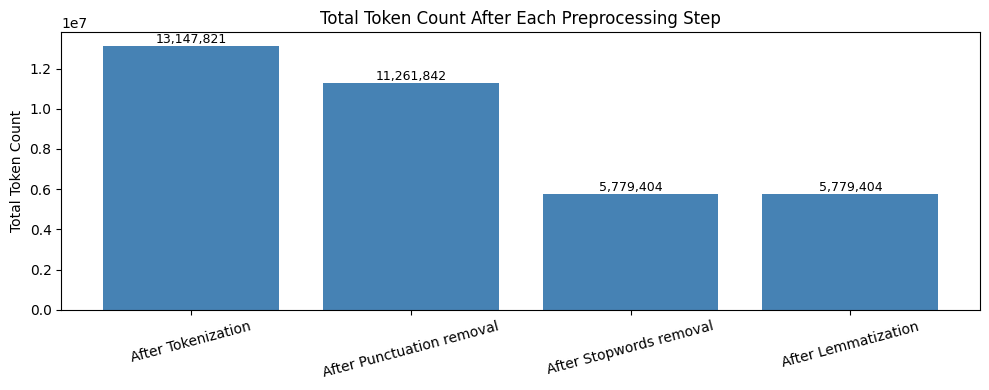

In [19]:
totals = {
    'After Tokenization': tokens_after_tokenization.apply(len).sum(),
    'After Punctuation removal': tokens_after_punctuation.apply(len).sum(),
    'After Stopwords removal': tokens_after_stopwords.apply(len).sum(),
    'After Lemmatization': tokens_after_lemmatization.apply(len).sum(),
}

plt.figure(figsize=(10, 4))
plt.bar(totals.keys(), totals.values(), color='steelblue')
plt.title('Total Token Count After Each Preprocessing Step')
plt.ylabel('Total Token Count')
plt.xticks(rotation=15)

for i, (step, count) in enumerate(totals.items()):
    plt.text(i, count, f'{count:,}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

In [ ]:
has_html = df['review'].apply(lambda x: bool(re.search(r'<.*?>', x))).sum()
print(f"Reviews with HTML tags: {has_html} / {len(df)} ({has_html/len(df)*100:.1f}%)")

example = df['review'][1]
print("\nBEFORE HTML removal:")
print(example[:300])
print("\nAFTER HTML removal:")
print(re.sub(r'<.*?>', '', example)[:300])

Reviews with HTML tags: 29202 / 50000 (58.4%)

BEFORE HTML removal:
A wonderful little production. <br /><br />The filming technique is very unassuming- very old-time-BBC fashion and gives a comforting, and sometimes discomforting, sense of realism to the entire piece. <br /><br />The actors are extremely well chosen- Michael Sheen not only "has got all the polari" 

AFTER HTML removal:
A wonderful little production. The filming technique is very unassuming- very old-time-BBC fashion and gives a comforting, and sometimes discomforting, sense of realism to the entire piece. The actors are extremely well chosen- Michael Sheen not only "has got all the polari" but he has all the voice


In [35]:
hyphen_words = []
for review in df['review']:
    words = review.split()
    for word in words:
        if '-' in word:
            hyphen_words.append(word)

pattern = re.compile(r'\w-\w')
has_hyphen = df['review'].apply(lambda x: bool(pattern.search(x))).sum()
print(f"Reviews with hyphenated words: {has_hyphen} / {len(df)}")
print(f"Total hyphenated words: {len(hyphen_words):,}")

example_review = df['review'][1]
print("\nBEFORE hyphen removal:")
print(example_review[:300])
print("\nAFTER hyphen removal:")
print(hyphen_step.run(example_review)[:300])


Reviews with hyphenated words: 27385 / 50000
Total hyphenated words: 109,598

BEFORE hyphen removal:
A wonderful little production. <br /><br />The filming technique is very unassuming- very old-time-BBC fashion and gives a comforting, and sometimes discomforting, sense of realism to the entire piece. <br /><br />The actors are extremely well chosen- Michael Sheen not only "has got all the polari" 

AFTER hyphen removal:
A wonderful little production. <br /><br />The filming technique is very unassuming  very old time BBC fashion and gives a comforting, and sometimes discomforting, sense of realism to the entire piece. <br /><br />The actors are extremely well chosen  Michael Sheen not only "has got all the polari" 


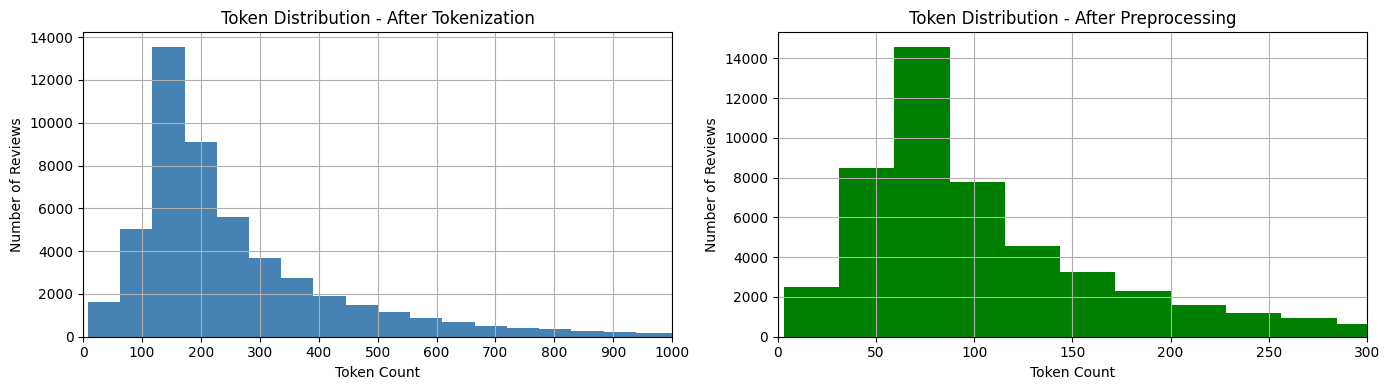

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

tokens_after_tokenization.apply(len).hist(bins=50, ax=axes[0], color='steelblue')
axes[0].set_title('Token Distribution - After Tokenization')
axes[0].set_xlabel('Token Count')
axes[0].set_ylabel('Number of Reviews')
axes[0].set_xlim(0, 1000)
axes[0].set_xticks(range(0, 1001, 100))

tokens_after_lemmatization.apply(len).hist(bins=50, ax=axes[1], color='green')
axes[1].set_title('Token Distribution - After Preprocessing')
axes[1].set_xlabel('Token Count')
axes[1].set_ylabel('Number of Reviews')
axes[1].set_xlim(0, 300)
axes[1].set_xticks(range(0, 301, 50))

plt.tight_layout()
plt.show()

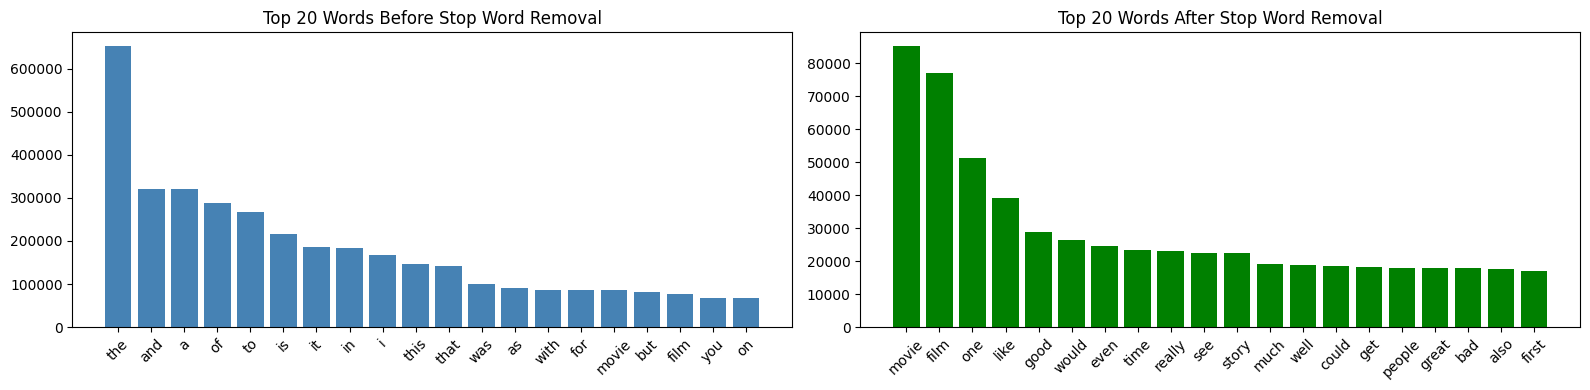

In [7]:
all_before = [t for tokens in tokens_after_punctuation for t in tokens]
all_after = [t for tokens in tokens_after_stopwords for t in tokens]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 4))

words_before, counts_before = zip(*Counter(all_before).most_common(20))
ax1.bar(words_before, counts_before, color='steelblue')
ax1.set_title('Top 20 Words Before Stop Word Removal')
ax1.tick_params(axis='x', rotation=45)

words_after, counts_after = zip(*Counter(all_after).most_common(20))
ax2.bar(words_after, counts_after, color='green')
ax2.set_title('Top 20 Words After Stop Word Removal')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [8]:
changed = [(before, after) 
           for tokens_b, tokens_a in zip(tokens_after_stopwords, tokens_after_lemmatization)
           for before, after in zip(tokens_b, tokens_a)
           if before != after]

print(f"Total changed words: {len(changed)}")

changes_counter = Counter([(b, a) for b, a in changed])

print("\nMost common changes:")
for (before, after), count in changes_counter.most_common(10):
    print(f"  {before:20} → {after:20} ({count} times)")

print("\nMost common changes (excluding plurals):")
count = 0
for (before, after), n in changes_counter.most_common(100):
    if not (before.endswith('s') and before[:-1] == after):
        print(f"  {before:20} → {after:20} ({n} times)")
        count += 1
    if count == 15:
        break

Total changed words: 594430

Most common changes:
  movies               → movie                (14760 times)
  characters           → character            (14153 times)
  films                → film                 (13455 times)
  scenes               → scene                (10201 times)
  actors               → actor                (8664 times)
  years                → year                 (8533 times)
  makes                → make                 (8281 times)
  us                   → u                    (7250 times)
  things               → thing                (7211 times)
  gets                 → get                  (6208 times)

Most common changes (excluding plurals):
  goes                 → go                   (4734 times)
  women                → woman                (3466 times)
  children             → child                (2993 times)
  lives                → life                 (2613 times)
  tries                → try                  (2420 times)
  stories          

In [ ]:
df['tokens_before'] = tokens_after_tokenization.apply(len)
df['tokens_after'] = tokens_after_lemmatization.apply(len)
df['cleaned'] = tokens_after_lemmatization.values 
df['tokens_removed'] = df['tokens_before'] - df['tokens_after']
df['removal_pct'] = (df['tokens_removed'] / df['tokens_before'] * 100).round(1)

print("=== Reviews with most tokens removed ===\n")
top_removed = df.nlargest(5, 'tokens_removed')
for _, row in top_removed.iterrows():
    print(f"Sentiment: {row['sentiment']}")
    print(f"Tokens: {row['tokens_before']} → {row['tokens_after']} ({row['removal_pct']}% removed)")
    print(f"Original: {row['review'][:200]}")
    print(f"Cleaned:  {row['cleaned'][:10]}")
    print()

=== Reviews with most tokens removed ===

Sentiment: positive
Tokens: 2535 → 1016 (59.9% removed)
Original: There's a sign on The Lost Highway that says:<br /><br />*MAJOR SPOILERS AHEAD*<br /><br />(but you already knew that, didn't you?)<br /><br />Since there's a great deal of people that apparently did 
Cleaned:  ['sign', 'lost', 'highway', 'say', 'major', 'spoiler', 'ahead', 'already', 'knew', 'since']

Sentiment: positive
Tokens: 2485 → 1081 (56.5% removed)
Original: (Some spoilers included:)<br /><br />Although, many commentators have called this film surreal, the term fits poorly here. To quote from Encyclopedia Britannica's, surreal means:<br /><br />"Fantastic
Cleaned:  ['spoiler', 'included', 'although', 'many', 'commentator', 'called', 'film', 'surreal', 'term', 'fit']

Sentiment: positive
Tokens: 2436 → 1092 (55.2% removed)
Original: Back in the mid/late 80s, an OAV anime by title of "Bubblegum Crisis" (which I think is a military slang term for when technical equipment go

In [ ]:
short = df[df['tokens_after'] <= 10].sort_values('tokens_after')

print(f"Reviews with ≤10 tokens after preprocessing: {len(short)}\n")
for _, row in short.head(10).iterrows():
    print(f"Tokens before: {row['tokens_before']} | Tokens after: {row['tokens_after']} | Sentiment: {row['sentiment']}")
    print(f"Original:  {row['review']}")
    print(f"Cleaned:   {row['cleaned']}")
    print()

Reviews with ≤10 tokens after preprocessing: 35

Tokens before: 9 | Tokens after: 3 | Sentiment: negative
Original:  I hope this group of film-makers never re-unites.
Cleaned:   ['hope', 'group', 'never']

Tokens before: 12 | Tokens after: 3 | Sentiment: negative
Original:  What a script, what a story, what a mess!
Cleaned:   ['script', 'story', 'mess']

Tokens before: 11 | Tokens after: 4 | Sentiment: negative
Original:  This movie is terrible but it has some good effects.
Cleaned:   ['movie', 'terrible', 'good', 'effect']

Tokens before: 8 | Tokens after: 4 | Sentiment: negative
Original:  Read the book, forget the movie!
Cleaned:   ['read', 'book', 'forget', 'movie']

Tokens before: 12 | Tokens after: 5 | Sentiment: negative
Original:  More suspenseful, more subtle, much, much more disturbing....
Cleaned:   ['suspenseful', 'subtle', 'much', 'much', 'disturbing']

Tokens before: 9 | Tokens after: 6 | Sentiment: negative
Original:  Primary plot!Primary direction!Poor interpretation.
C

In [36]:
# Bez hyphen removal
text_no_hyphen = df['review'].apply(html_step.run).apply(tokenize_step.run).apply(punctuation_step.run)

# Sa hyphen removal
text_with_hyphen = df['review'].apply(html_step.run).apply(hyphen_step.run).apply(tokenize_step.run).apply(punctuation_step.run)

print(f"Without hyphen removal: {text_no_hyphen.apply(len).sum():,} tokens")
print(f"With hyphen removal:    {text_with_hyphen.apply(len).sum():,} tokens")
print(f"Difference:             {text_with_hyphen.apply(len).sum() - text_no_hyphen.apply(len).sum():,} tokens")

Without hyphen removal: 11,098,973 tokens
With hyphen removal:    11,262,442 tokens
Difference:             163,469 tokens


In [34]:
hyphen_reviews = df[df['review'].apply(
    lambda x: bool(re.search(r'\w-\w', html_step.run(x)))
)].head(5)

for _, row in hyphen_reviews.iterrows():
    idx = row.name
    cleaned_review = html_step.run(row['review'])
    hyphen_words = [w for w in cleaned_review.split() if re.search(r'\w-\w', w)]
    
    for word in hyphen_words[:3]:
        after_hyphen = hyphen_step.run(word)
        after_lower = lower_step.run(after_hyphen)
        after_tokenize = tokenize_step.run(after_lower)
        after_punct = punctuation_step.run(after_tokenize)
        after_stopwords = stopwords_step.run(after_punct)
        after_lemma = lemmatization_step.run(after_stopwords)
        
        print(f"  {word:25} → hyphen: {after_hyphen:20} → tokens: {after_tokenize} → final: {after_lemma}")
    print()

  old-time-BBC              → hyphen: old time BBC         → tokens: ['old', 'time', 'bbc'] → final: ['old', 'time', 'bbc']

  light-hearted             → hyphen: light hearted        → tokens: ['light', 'hearted'] → final: ['light', 'hearted']

  all-time                  → hyphen: all time             → tokens: ['all', 'time'] → final: ['time']
  "dressed-up               → hyphen: "dressed up          → tokens: ['``', 'dressed', 'up'] → final: ['dressed']

  guest-hosts,              → hyphen: guest hosts,         → tokens: ['guest', 'hosts', ','] → final: ['guest', 'host']
  hand-selected             → hyphen: hand selected        → tokens: ['hand', 'selected'] → final: ['hand', 'selected']

  1-score                   → hyphen: 1 score              → tokens: ['1', 'score'] → final: ['score']



In [41]:
os.makedirs("../results", exist_ok=True)

df_to_save = df[['review', 'sentiment']].copy()
df_to_save['cleaned'] = tokens_after_lemmatization.values

df_to_save.to_pickle("../results/preprocessed.pkl")
print("Saved to ../results/preprocessed.pkl")
print(df_to_save.head())

Saved to ../results/preprocessed.pkl
                                              review sentiment  \
0  One of the other reviewers has mentioned that ...  positive   
1  A wonderful little production. <br /><br />The...  positive   
2  I thought this was a wonderful way to spend ti...  positive   
3  Basically there's a family where a little boy ...  negative   
4  Petter Mattei's "Love in the Time of Money" is...  positive   

                                             cleaned  
0  [one, reviewer, mentioned, watching, oz, episo...  
1  [wonderful, little, production, filming, techn...  
2  [thought, wonderful, way, spend, time, hot, su...  
3  [basically, family, little, boy, jake, think, ...  
4  [petter, mattei, love, time, money, visually, ...  
